In [65]:
import vos
import os
import h5py
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import matplotlib.gridspec
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [66]:
# Anonymous client (no login needed for public data)
client = vos.Client()

vospace_dir = "vos:AstroDataCitationDOI/CISTI.CANFAR/25.0066/data/dynamic_spectra/data"
output_dir = "./chime_dynamic_spectra"
os.makedirs(output_dir, exist_ok=True)

# List all files in the directory
print("Fetching file list...")
files = client.listdir(vospace_dir)
print(f"Found {len(files)} files.")

Fetching file list...
Found 4536 files.


In [67]:
with open('downloaded_files.txt', 'r') as f:
    downloaded_files = set(line.strip() for line in f)

In [68]:
def analyse_burst(file_name):
    dt = 0.009830400085775182*1000  # ms, from metadata in the hdf5 file

    with h5py.File(file_name, "r") as f:
        wfall = f["data"][:]
        good_freq = f["good_freq"][:]
        freqs = f["index_map"]["freqs"][:]
        
    wfall[~good_freq, :] = np.nan
    ts = np.nansum(wfall, axis=0)

    def boxcar_kernel(width):
        width = int(round(width, 0))
        return np.ones(width, dtype="float32") / np.sqrt(width)

    def find_burst(ts, min_width=1, max_width=128):
        min_width = int(min_width)
        max_width = int(max_width)
        # do not search widths bigger than timeseries
        widths = list(range(min_width, min(max_width + 1, len(ts)-2)))
        # envelope finding
        snrs = np.empty_like(widths, dtype=float)
        peaks = np.empty_like(widths, dtype=int)
        for i in range(len(widths)):
            convolved = scipy.signal.convolve(ts, boxcar_kernel(widths[i]), mode="same")
            peaks[i] = np.nanargmax(convolved)
            snrs[i] = convolved[peaks[i]]
        best_idx = np.nanargmax(snrs)
        return peaks[best_idx], widths[best_idx], snrs[best_idx]

    peak, width, snr = find_burst(ts)
    
    plot_time = (np.arange(len(ts)) - peak) * dt
    extent = [plot_time.min(), plot_time.max(), freqs[0], freqs[-1]]

    def bin_freq_channels(data, fbin_factor=16):
        n_chan, n_time = data.shape
        return np.nanmean(data[:(n_chan//fbin_factor)*fbin_factor].reshape(-1, fbin_factor, n_time), axis=1)

    wfall_plot = bin_freq_channels(wfall, 64)#64=256channels,128=128channels
    wfall_plot[np.isnan(wfall_plot)] = np.nanmedian(wfall_plot)
    
    return wfall_plot, extent

In [69]:
pbar = tqdm(enumerate(files), total=len(files), unit="file")

for i, filename in pbar:
    # Update the progress bar description with the current filename
        pbar.set_description(f"Processing {filename}")
        remote_path = f"{vospace_dir}/{filename}"
        local_path = os.path.join(output_dir, filename)

        
        if filename in downloaded_files:
            # print(f"[{i+1}/{len(files)}] Skipping already downloaded: {filename}")
            continue
        try:
            client.copy(remote_path, local_path)
            
            file = h5py.File(local_path, 'r')
            name = filename.split('_')[0]
            
            wfall_plot, extent = analyse_burst(local_path)
            
            # save data to global hdf5 file 
            
            with h5py.File('all_bursts.hdf5', 'a') as f:
                if name not in f:
                    f.create_group(name)
                f[name].create_dataset('wfall_plot', data=wfall_plot)
                f[name].create_dataset('extent', data=extent)
                
            downloaded_files.add(filename)
            with open('downloaded_files.txt', 'a') as f:
                f.write(filename + '\n')
            
            #delete local file to save space
            os.remove(local_path)

        except Exception as e:
            print(f"  ERROR on {filename}: {e}")

Processing FRB20230915H_stokesi_dynamic_spectrum.h5: 100%|██████████| 4536/4536 [1:09:06<00:00,  1.09file/s]


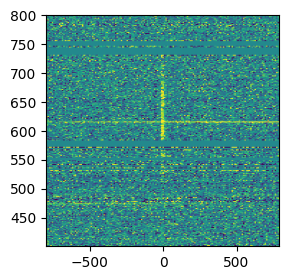

In [ ]:
# read all_bursts.hdf5 and plot one burst

with h5py.File('all_bursts.hdf5', 'r') as f:
    burst_name = list(f.keys())[0]
    wfall_plot = f[burst_name]['wfall_plot'][:]
    extent = f[burst_name]['extent'][:]
    
plt.figure(figsize=(6, 4))
gs = matplotlib.gridspec.GridSpec(2, 2, height_ratios=[1, 3], hspace=0.0, wspace=0.0)
data_im = plt.subplot(gs[2])
cmap = plt.cm.viridisa
vmin, vmax = np.nanpercentile(wfall_plot, [1, 99])
im = data_im.imshow(wfall_plot, aspect="auto", origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)


In [71]:
# get size of hdf5 file
file_size = os.path.getsize('all_bursts.hdf5')
file_size_mb = file_size / (1024 * 1024)
print(f"Size of all_bursts.hdf5: {file_size_mb:.2f} MB")

Size of all_bursts.hdf5: 777.02 MB
